In [1]:
cd '/home/tomas/phoenix'

/home/tomas/phoenix


/home/tomas/miniconda3/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
def _print_nonzeros(label: str, adaa, N: int, keymap, max_print: int = 50) -> int:
    print(label)

    shown = 0
    total = 0

    for i in range(adaa.size):
        v = adaa.data["real"][i]
        if abs(v) > 1e-12:
            total += 1

            if shown < max_print:
                nums, word = keymap.off2key(i).labels
                full = ["I"] * N
                for s, w in zip(nums, word):
                    full[int(s)] = str(w).upper()
                print(" ", "".join(full), float(v))
                shown += 1

    if total == 0:
        print("  (empty)")
    else:
        print(f"\n  → total nonzero terms: {total}")

    return total


In [3]:
# ============================================================
# Single notebook cell:
# N=7 XYZ NN, <Z0(t)>
# exact (QuTiP) vs covar vs HS
# fixed m, fixed ell, same physical initial state sigma0_z
# ============================================================

import math
import numpy as np
import pytest
import time
import qutip as qt

from adaptHeisenberg.sigma0 import ProductState
from adaptHeisenberg.buffer_free_commutator_builder import build_commutator_buffered
from adaptHeisenberg.evolution import SystemBackend, FrozenBasisEvolver

from adaptHeisenberg.io_runlog import make_run_id, export_run

# ============================================================
# Helpers
# ============================================================
def tail_weight_fraction(phi: np.ndarray, p: int, gram: np.ndarray | None = None) -> float:
    """
    Tail weight fraction of the last p coefficients.

    If gram is None, use the Euclidean norm:
        sum_{last p} |phi|^2 / sum_all |phi|^2

    If gram is given, use the Gram-induced quadratic form:
        (phi_tail^T G_tail phi_tail) / (phi^T G phi)

    Parameters
    ----------
    phi : np.ndarray
        Coefficient vector in the current basis.
    p : int
        Number of last coefficients to monitor.
    gram : np.ndarray | None
        Gram matrix of the current basis. If provided, the tail weight is
        computed in the Gram metric.

    Returns
    -------
    float
        Tail weight fraction in [0, +inf) numerically; ideally in [0,1]
        if gram is positive semidefinite and the basis ordering is meaningful.
    """
    phi = np.asarray(phi, dtype=float)

    if p <= 0:
        return 0.0
    if phi.ndim != 1:
        raise ValueError(f"phi must be 1D, got shape {phi.shape}")

    p = min(p, len(phi))

    if gram is None:
        denom = float(np.sum(np.abs(phi) ** 2))
        if denom == 0.0:
            return 0.0
        numer = float(np.sum(np.abs(phi[-p:]) ** 2))
        return numer / denom

    gram = np.asarray(gram, dtype=float)
    if gram.shape != (len(phi), len(phi)):
        raise ValueError(
            f"gram must have shape {(len(phi), len(phi))}, got {gram.shape}"
        )

    denom = float(phi @ gram @ phi)
    if abs(denom) < 1e-30:
        return 0.0

    phi_tail = phi[-p:]
    gram_tail = gram[-p:, -p:]
    numer = float(phi_tail @ gram_tail @ phi_tail)

    return numer / denom


def expect_operator_sigma0(sigma0, O, *, eps=0.0) -> float:
    """
    Compute Tr(sigma0 O) for an ADAA operator O represented as a sum of Pauli terms.
    Assumes real coefficients.
    """
    km = type(O)._KEYMAP
    arr = O.data["real"]
    nz = np.flatnonzero(np.abs(arr) > eps)

    out = 0.0
    for off in nz:
        coeff = float(arr[off])
        nums, word = km.off2key(int(off)).labels
        out += coeff * sigma0.expect_reduced(tuple(nums), str(word))
    return float(out)


# ============================================================
# Parameters
# ============================================================
N = 7
site = 0

m_small = 3     # fixed m
ell = 6          # fixed ell

Jx = 1.
Jy = -1
Jz = 0.25

sigma0_z = 0.95  # same physical initial state for all comparisons

p_tail = 2
eps_tail = 1e99

tmax = 1.
n_steps = 100
dt = tmax / n_steps
times = np.linspace(0.0, tmax, n_steps + 1)

# ============================================================
# Exact dynamics with QuTiP
# ============================================================
sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()
id2 = qt.qeye(2)

def op_on_site(op, i, N):
    ops = [id2] * N
    ops[i] = op
    return qt.tensor(ops)

def op_on_two_sites(op1, i, op2, j, N):
    ops = [id2] * N
    ops[i] = op1
    ops[j] = op2
    return qt.tensor(ops)

Hq = 0
for j in range(N - 1):
    Hq += Jx * op_on_two_sites(sx, j, sx, j + 1, N)
    Hq += Jy * op_on_two_sites(sy, j, sy, j + 1, N)
    Hq += Jz * op_on_two_sites(sz, j, sz, j + 1, N)

rho1 = 0.5 * (id2 + 0.4 * sx + 0.8*sy + 0.3*sz)
rho0 = qt.tensor([rho1 for _ in range(N)])
Z0_q = op_on_site(sz, site, N)

res = qt.mesolve(Hq, rho0, times, c_ops=[], e_ops=[Z0_q])
exact = np.real(np.asarray(res.expect[0], dtype=float))

# ============================================================
# Build Phoenix backend
# ============================================================
commutate, SystemSmall, SystemBig, HamiltonADAA, km_small, km_big, km_ham = build_commutator_buffered(
    num_spins=N,
    m_small=m_small,
    h_body_max=2,
    real_only=True,
    recompile=True,
)

comm_raw = commutate

def commutate_zeroed(*, rho, ham):
    res = SystemBig()
    res.to_zero()
    try:
        out = - comm_raw(rho=rho, ham=ham, res=res)
    except TypeError:
        return comm_raw(rho=rho, ham=ham)
    return res if out is None else out

backend = SystemBackend(
    commutate=commutate_zeroed,
    SystemSmall=SystemSmall,
    SystemBig=SystemBig,
    HamiltonADAA=HamiltonADAA,
    km_small=km_small,
    km_big=km_big,
    km_ham=km_ham,
)

# ============================================================
# Build XYZ Hamiltonian in Phoenix
# ============================================================
H = HamiltonADAA()
H.to_zero()

for j in range(N - 1):
    H.data["real"][km_ham.key2off((j, j + 1), "xx")] = Jx
    H.data["real"][km_ham.key2off((j, j + 1), "yy")] = Jy
    H.data["real"][km_ham.key2off((j, j + 1), "zz")] = Jz

# ============================================================
# Same physical state for measured expectations
# ============================================================
sigma_phys = ProductState([0.4, 0.8, 0.3] * N)

# Covariance projection state
sigma_covar = sigma_phys

# HS projection state:
# maximally mixed product state => covariance scalar product reduces to HS up to a constant
sigma_hs = ProductState([0.0, 0.0, 0.0] * N)

# Observable seed b0 = Z0
b0 = SystemSmall()
b0.to_zero()
b0.data["real"][km_small.key2off((site,), "z")] = 0.5

# ============================================================
# Evolvers
# ============================================================


PINV_RTOL = 1e-12 
evolver_covar = FrozenBasisEvolver(
    backend=backend,
    ham=H,
    sigma0=sigma_covar,
    m_small=m_small,
    ell=ell,
    exclude_scalar=False,
    pinv_rtol=PINV_RTOL,
).build(b0)

evolver_hs = FrozenBasisEvolver(
    backend=backend,
    ham=H,
    sigma0=sigma_hs,
    m_small=m_small,
    ell=ell,
    exclude_scalar=False,
    pinv_rtol=PINV_RTOL,
).build(b0)


# initial coordinates in each basis
phi_covar = np.zeros(len(evolver_covar.basis))
phi_covar[0] = 1.0

phi_hs = np.zeros(len(evolver_hs.basis))
phi_hs[0] = 1.0

# ============================================================
# Time evolution helper
# ============================================================
def run_projected(evolver, phi0, sigma_measure, dt, times, p_tail=2, eps_tail=eps_tail):
    phi = np.array(phi0, dtype=float).copy()

    obs_vals = []
    tail_vals = []
    rebuilt_vals = []

    for istep, t in enumerate(times):
        O_curr = evolver.assemble_operator(phi)
        ev = expect_operator_sigma0(sigma_measure, O_curr, eps=1e-15)

        frac = tail_weight_fraction(phi, p_tail, gram=evolver.gram)
        rebuilt = False

        if frac >= eps_tail:
            evolver = FrozenBasisEvolver(
                backend=evolver.backend,
                ham=evolver.ham,
                sigma0=evolver.sigma0,
                m_small=evolver.m_small,
                ell=evolver.ell,
                exclude_scalar=False,
                pinv_rtol=PINV_RTOL,
            ).build(O_curr)

            phi = evolver.project_operator(O_curr)
            rebuilt = True

            O_curr = evolver.assemble_operator(phi)
            ev = expect_operator_sigma0(sigma_measure, O_curr, eps=1e-15)
            frac = tail_weight_fraction(phi, p_tail, gram=evolver.gram)
        
        obs_vals.append(float(ev))
        tail_vals.append(float(frac))
        rebuilt_vals.append(bool(rebuilt))

        if istep < len(times) - 1:
            phi = evolver.step_expm(phi, dt)

    return (
        np.asarray(obs_vals, dtype=float),
        np.asarray(tail_vals, dtype=float),
        np.asarray(rebuilt_vals, dtype=bool),
    )

# ============================================================
# Run both projected evolutions
# ============================================================
y_covar, tail_covar, rebuilt_covar = run_projected(
    evolver=evolver_covar,
    phi0=phi_covar,
    sigma_measure=sigma_phys,
    dt=dt,
    times=times,
    p_tail=p_tail,
    eps_tail=eps_tail,
)

y_hs, tail_hs, rebuilt_hs = run_projected(
    evolver=evolver_hs,
    phi0=phi_hs,
    sigma_measure=sigma_phys,
    dt=dt,
    times=times,
    p_tail=p_tail,
    eps_tail=eps_tail,
)

# ============================================================
# Diagnostics
# ============================================================
err_covar = np.abs(y_covar - exact/2)
err_hs = np.abs(y_hs - exact/2)

print("N =", N, "m =", m_small, "ell =", ell)
print("max |covar - exact| =", np.max(err_covar))
print("max |HS - exact|    =", np.max(err_hs))
print("covar rebuilds =", int(np.sum(rebuilt_covar)))
print("HS rebuilds    =", int(np.sum(rebuilt_hs)))



ham 2-body domains: 28
Cannot use distutils backend with Python>=3.12, using meson backend instead.
Using meson backend
Will pass --lower to f2py
See https://numpy.org/doc/stable/f2py/buildtools/meson.html
Reading fortran codes...
	Reading file 'pauli_library_comm_buf.f90' (format:free)
Post-processing...
	Block: ecplib_comm_buf
			Block: pauli_library_comm_buf
				Block: commutate_000_part000
				Block: commutate_000
				Block: commutate_001_part000
				Block: commutate_001
				Block: commutate_002_part000
				Block: commutate_002
				Block: commutate_003_part000
				Block: commutate_003
				Block: commutate_004_part000
				Block: commutate_004
				Block: commutate_005_part000
				Block: commutate_005
				Block: commutate_006_part000
				Block: commutate_006
				Block: commutate_007_part000
				Block: commutate_007
				Block: commutate_008_part000
				Block: commutate_008
				Block: commutate_009_part000
				Block: commutate_009
				Block: commutate_010_part000
				Block: commutate_01

              commutate_002(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_003_part000"...
              commutate_003_part000(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_003"...
              commutate_003(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_004_part000"...
              commutate_004_part000(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_004"...
              commutate_004(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_005_part000"...
              commutate_005_part000(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_005"...
              commutate_005(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library

The Meson build system
Version: 1.3.2
Source dir: /tmp/tmp9fumv7va
Build dir: /tmp/tmp9fumv7va/bbdir
Build type: native build
Project name: ecplib_comm_buf
Project version: 0.1
Fortran compiler for the host machine: gfortran (gcc 13.3.0 "GNU Fortran (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0")
Fortran linker for the host machine: gfortran ld.bfd 2.42
C compiler for the host machine: cc (gcc 13.3.0 "cc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0")
C linker for the host machine: cc ld.bfd 2.42
Host machine cpu family: x86_64
Host machine cpu: x86_64
Program /home/tomas/miniconda3/bin/python found: YES (/home/tomas/miniconda3/bin/python)
Found pkg-config: YES (/usr/bin/pkg-config) 1.8.1
Run-time dependency python found: YES 3.12
Library quadmath found: YES
Build targets in project: 1

Found ninja-1.11.1 at /usr/bin/ninja
ninja: Entering directory `/tmp/tmp9fumv7va/bbdir'
[1/6] Module scanner.
[2/6] Compiling C object ecplib_comm_buf.cpython-312-x86_64-linux-gnu.so.p/6429abe6ab6341934029714386c8c

In [4]:
0.4**2+0.8**2+0.4**2

0.9600000000000002

In [5]:
import matplotlib.pyplot as plt

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_14529/3741764958.py:24: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_title(f"XYZ NN, N={N}, m={m_small}, ell={ell}, $(\mu_x, \mu_y, \mu_z) = (0.4,0.8,0.3)$")


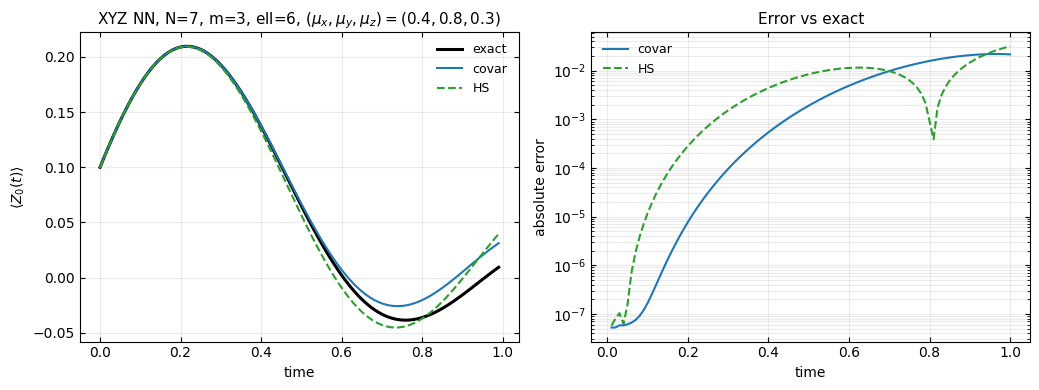

In [13]:
# ============================================================
# Plot
# ============================================================
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.0))
nmax = -1

# expectation values
ax[0].plot(times[:nmax], exact[:nmax]/2, color="black", lw=2.2, label="exact")
ax[0].plot(times[:nmax], y_covar[:nmax], color="tab:blue", label="covar")
ax[0].plot(times[:nmax], y_hs[:nmax], color="tab:green", ls="--", label="HS")
ax[0].set_xlabel("time")
ax[0].set_ylabel(r"$\langle Z_0(t)\rangle$")
ax[0].set_title(f"XYZ NN, N={N}, m={m_small}, ell={ell}, $(\mu_x, \mu_y, \mu_z) = (0.4,0.8,0.3)$")
ax[0].grid(alpha=0.25)
ax[0].legend(frameon=False)

# absolute errors
ax[1].plot(times[1:], err_covar[1:], color="tab:blue", label="covar")
ax[1].plot(times[1:], err_hs[1:], color="tab:green", ls="--", label="HS")
ax[1].set_xlabel("time")
ax[1].set_ylabel("absolute error")
ax[1].set_yscale("log")
ax[1].set_title("Error vs exact")
ax[1].grid(alpha=0.25, which="both")
ax[1].legend(frameon=False)

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Single notebook cell:
# N=7 XYZ NN, <Z0(t)>
# exact (QuTiP) vs covar vs HS
# fixed m, fixed ell, same physical initial state sigma0_z
# ============================================================

import math
import numpy as np
import pytest
import time
import qutip as qt

from adaptHeisenberg.sigma0 import ProductState
from adaptHeisenberg.buffer_free_commutator_builder import build_commutator_buffered
from adaptHeisenberg.evolution import SystemBackend, FrozenBasisEvolver

from adaptHeisenberg.io_runlog import make_run_id, export_run

# ============================================================
# Helpers
# ============================================================
def tail_weight_fraction(phi: np.ndarray, p: int, gram: np.ndarray | None = None) -> float:
    """
    Tail weight fraction of the last p coefficients.

    If gram is None, use the Euclidean norm:
        sum_{last p} |phi|^2 / sum_all |phi|^2

    If gram is given, use the Gram-induced quadratic form:
        (phi_tail^T G_tail phi_tail) / (phi^T G phi)

    Parameters
    ----------
    phi : np.ndarray
        Coefficient vector in the current basis.
    p : int
        Number of last coefficients to monitor.
    gram : np.ndarray | None
        Gram matrix of the current basis. If provided, the tail weight is
        computed in the Gram metric.

    Returns
    -------
    float
        Tail weight fraction in [0, +inf) numerically; ideally in [0,1]
        if gram is positive semidefinite and the basis ordering is meaningful.
    """
    phi = np.asarray(phi, dtype=float)

    if p <= 0:
        return 0.0
    if phi.ndim != 1:
        raise ValueError(f"phi must be 1D, got shape {phi.shape}")

    p = min(p, len(phi))

    if gram is None:
        denom = float(np.sum(np.abs(phi) ** 2))
        if denom == 0.0:
            return 0.0
        numer = float(np.sum(np.abs(phi[-p:]) ** 2))
        return numer / denom

    gram = np.asarray(gram, dtype=float)
    if gram.shape != (len(phi), len(phi)):
        raise ValueError(
            f"gram must have shape {(len(phi), len(phi))}, got {gram.shape}"
        )

    denom = float(phi @ gram @ phi)
    if abs(denom) < 1e-30:
        return 0.0

    phi_tail = phi[-p:]
    gram_tail = gram[-p:, -p:]
    numer = float(phi_tail @ gram_tail @ phi_tail)

    return numer / denom


def expect_operator_sigma0(sigma0, O, *, eps=0.0) -> float:
    """
    Compute Tr(sigma0 O) for an ADAA operator O represented as a sum of Pauli terms.
    Assumes real coefficients.
    """
    km = type(O)._KEYMAP
    arr = O.data["real"]
    nz = np.flatnonzero(np.abs(arr) > eps)

    out = 0.0
    for off in nz:
        coeff = float(arr[off])
        nums, word = km.off2key(int(off)).labels
        out += coeff * sigma0.expect_reduced(tuple(nums), str(word))
    return float(out)


# ============================================================
# Parameters
# ============================================================
N = 7
site = 0

m_small = 3      # fixed m
ell = 6          # fixed ell

Jx = 1.
Jy = -1
Jz = 0.25

sigma0_z = 0.95  # same physical initial state for all comparisons

p_tail = 2
eps_tail = 1e99

tmax = 1.
n_steps = 100
dt = tmax / n_steps
times = np.linspace(0.0, tmax, n_steps + 1)

# ============================================================
# Exact dynamics with QuTiP
# ============================================================
sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()
id2 = qt.qeye(2)

def op_on_site(op, i, N):
    ops = [id2] * N
    ops[i] = op
    return qt.tensor(ops)

def op_on_two_sites(op1, i, op2, j, N):
    ops = [id2] * N
    ops[i] = op1
    ops[j] = op2
    return qt.tensor(ops)

Hq = 0
for j in range(N - 1):
    Hq += Jx * op_on_two_sites(sx, j, sx, j + 1, N)
    Hq += Jy * op_on_two_sites(sy, j, sy, j + 1, N)
    Hq += Jz * op_on_two_sites(sz, j, sz, j + 1, N)

rho1 = 0.5 * (id2 + 0.6 * sx + 0.75 * sy + 0.2 * sz)    
rho0 = qt.tensor([rho1 for _ in range(N)])
Z0_q = op_on_site(sz, site, N)

res = qt.mesolve(Hq, rho0, times, c_ops=[], e_ops=[Z0_q])
exact = np.real(np.asarray(res.expect[0], dtype=float))

# ============================================================
# Build Phoenix backend
# ============================================================
commutate, SystemSmall, SystemBig, HamiltonADAA, km_small, km_big, km_ham = build_commutator_buffered(
    num_spins=N,
    m_small=m_small,
    h_body_max=2,
    real_only=True,
    recompile=True,
)

comm_raw = commutate

def commutate_zeroed(*, rho, ham):
    res = SystemBig()
    res.to_zero()
    try:
        out = -1*comm_raw(rho=rho, ham=ham, res=res)
    except TypeError:
        return comm_raw(rho=rho, ham=ham)
    return res if out is None else out

backend = SystemBackend(
    commutate=commutate_zeroed,
    SystemSmall=SystemSmall,
    SystemBig=SystemBig,
    HamiltonADAA=HamiltonADAA,
    km_small=km_small,
    km_big=km_big,
    km_ham=km_ham,
)

# ============================================================
# Build XYZ Hamiltonian in Phoenix
# ============================================================
H = HamiltonADAA()
H.to_zero()

for j in range(N - 1):
    H.data["real"][km_ham.key2off((j, j + 1), "xx")] = Jx
    H.data["real"][km_ham.key2off((j, j + 1), "yy")] = Jy
    H.data["real"][km_ham.key2off((j, j + 1), "zz")] = Jz

# ============================================================
# Same physical state for measured expectations
# ============================================================
sigma_phys = ProductState([0.6, 0.75, 0.2] * N)
# Covariance projection state
sigma_covar = sigma_phys

# HS projection state:
# maximally mixed product state => covariance scalar product reduces to HS up to a constant
sigma_hs = ProductState([0.0, 0.0, 0.0] * N)

# Observable seed b0 = Z0
b0 = SystemSmall()
b0.to_zero()
b0.data["real"][km_small.key2off((site,), "z")] = 0.5

# ============================================================
# Evolvers
# ============================================================


PINV_RTOL = 1e-12 
evolver_covar = FrozenBasisEvolver(
    backend=backend,
    ham=H,
    sigma0=sigma_covar,
    m_small=m_small,
    ell=ell,
    exclude_scalar=False,
    pinv_rtol=PINV_RTOL,
).build(b0)

evolver_hs = FrozenBasisEvolver(
    backend=backend,
    ham=H,
    sigma0=sigma_hs,
    m_small=m_small,
    ell=ell,
    exclude_scalar=False,
    pinv_rtol=PINV_RTOL,
).build(b0)


# initial coordinates in each basis
phi_covar = np.zeros(len(evolver_covar.basis))
phi_covar[0] = 1.0

phi_hs = np.zeros(len(evolver_hs.basis))
phi_hs[0] = 1.0

# ============================================================
# Time evolution helper
# ============================================================
def run_projected(evolver, phi0, sigma_measure, dt, times, p_tail=2, eps_tail=eps_tail):
    phi = np.array(phi0, dtype=float).copy()

    obs_vals = []
    tail_vals = []
    rebuilt_vals = []

    for istep, t in enumerate(times):
        O_curr = evolver.assemble_operator(phi)
        ev = expect_operator_sigma0(sigma_measure, O_curr, eps=1e-15)

        frac = tail_weight_fraction(phi, p_tail, gram=evolver.gram)
        rebuilt = False

        if frac >= eps_tail:
            evolver = FrozenBasisEvolver(
                backend=evolver.backend,
                ham=evolver.ham,
                sigma0=evolver.sigma0,
                m_small=evolver.m_small,
                ell=evolver.ell,
                exclude_scalar=False,
                pinv_rtol=PINV_RTOL,
            ).build(O_curr)

            phi = evolver.project_operator(O_curr)
            rebuilt = True

            O_curr = evolver.assemble_operator(phi)
            ev = expect_operator_sigma0(sigma_measure, O_curr, eps=1e-15)
            frac = tail_weight_fraction(phi, p_tail, gram=evolver.gram)
        
        obs_vals.append(float(ev))
        tail_vals.append(float(frac))
        rebuilt_vals.append(bool(rebuilt))

        if istep < len(times) - 1:
            phi = evolver.step_expm(phi, dt)

    return (
        np.asarray(obs_vals, dtype=float),
        np.asarray(tail_vals, dtype=float),
        np.asarray(rebuilt_vals, dtype=bool),
    )

# ============================================================
# Run both projected evolutions
# ============================================================
y_covar, tail_covar, rebuilt_covar = run_projected(
    evolver=evolver_covar,
    phi0=phi_covar,
    sigma_measure=sigma_phys,
    dt=dt,
    times=times,
    p_tail=p_tail,
    eps_tail=eps_tail,
)

y_hs, tail_hs, rebuilt_hs = run_projected(
    evolver=evolver_hs,
    phi0=phi_hs,
    sigma_measure=sigma_phys,
    dt=dt,
    times=times,
    p_tail=p_tail,
    eps_tail=eps_tail,
)

# ============================================================
# Diagnostics
# ============================================================
err_covar = np.abs(y_covar - exact/2)
err_hs = np.abs(y_hs - exact/2)

print("N =", N, "m =", m_small, "ell =", ell)
print("max |covar - exact| =", np.max(err_covar))
print("max |HS - exact|    =", np.max(err_hs))
print("covar rebuilds =", int(np.sum(rebuilt_covar)))
print("HS rebuilds    =", int(np.sum(rebuilt_hs)))



ham 2-body domains: 28
Cannot use distutils backend with Python>=3.12, using meson backend instead.
Using meson backend
Will pass --lower to f2py
See https://numpy.org/doc/stable/f2py/buildtools/meson.html
Reading fortran codes...
	Reading file 'pauli_library_comm_buf.f90' (format:free)
Post-processing...
	Block: ecplib_comm_buf
			Block: pauli_library_comm_buf
				Block: commutate_000_part000
				Block: commutate_000
				Block: commutate_001_part000
				Block: commutate_001
				Block: commutate_002_part000
				Block: commutate_002
				Block: commutate_003_part000
				Block: commutate_003
				Block: commutate_004_part000
				Block: commutate_004
				Block: commutate_005_part000
				Block: commutate_005
				Block: commutate_006_part000
				Block: commutate_006
				Block: commutate_007_part000
				Block: commutate_007
				Block: commutate_008_part000
				Block: commutate_008
				Block: commutate_009_part000
				Block: commutate_009
				Block: commutate_010_part000
				Block: commutate_01

              commutate_002(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_003_part000"...
              commutate_003_part000(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_003"...
              commutate_003(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_004_part000"...
              commutate_004_part000(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_004"...
              commutate_004(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_005_part000"...
              commutate_005_part000(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library_comm_buf.commutate_005"...
              commutate_005(res_real,rho_real,ham_real)
            Constructing wrapper function "pauli_library

The Meson build system
Version: 1.3.2
Source dir: /tmp/tmp2hvvfiuk
Build dir: /tmp/tmp2hvvfiuk/bbdir
Build type: native build
Project name: ecplib_comm_buf
Project version: 0.1
Fortran compiler for the host machine: gfortran (gcc 13.3.0 "GNU Fortran (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0")
Fortran linker for the host machine: gfortran ld.bfd 2.42
C compiler for the host machine: cc (gcc 13.3.0 "cc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0")
C linker for the host machine: cc ld.bfd 2.42
Host machine cpu family: x86_64
Host machine cpu: x86_64
Program /home/tomas/miniconda3/bin/python found: YES (/home/tomas/miniconda3/bin/python)
Found pkg-config: YES (/usr/bin/pkg-config) 1.8.1
Run-time dependency python found: YES 3.12
Library quadmath found: YES
Build targets in project: 1

Found ninja-1.11.1 at /usr/bin/ninja
ninja: Entering directory `/tmp/tmp2hvvfiuk/bbdir'
[1/6] Module scanner.
[2/6] Compiling C object ecplib_comm_buf.cpython-312-x86_64-linux-gnu.so.p/6429abe6ab6341934029714386c8c

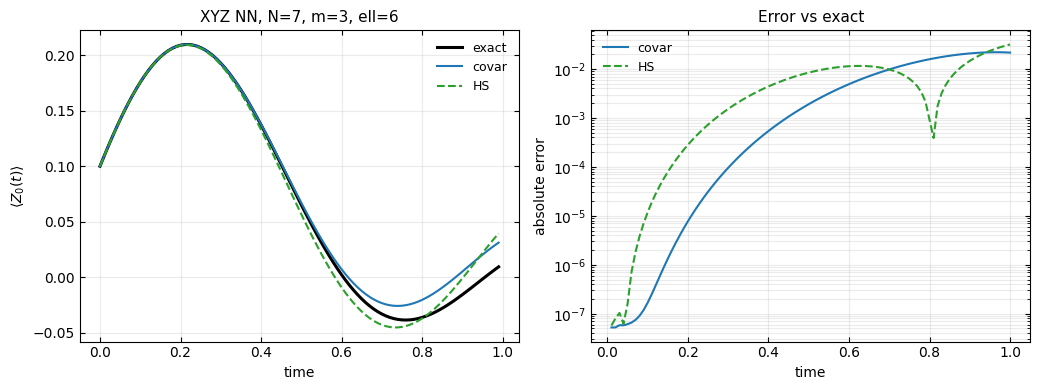

In [14]:
import matplotlib.pyplot as plt
# ============================================================
# Plot
# ============================================================
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.0))
nmax = -1

# expectation values
ax[0].plot(times[:nmax], exact[:nmax]/2, color="black", lw=2.2, label="exact")
ax[0].plot(times[:nmax], y_covar[:nmax], color="tab:blue", label="covar")
ax[0].plot(times[:nmax], y_hs[:nmax], color="tab:green", ls="--", label="HS")
ax[0].set_xlabel("time")
ax[0].set_ylabel(r"$\langle Z_0(t)\rangle$")
ax[0].set_title(f"XYZ NN, N={N}, m={m_small}, ell={ell}")
ax[0].grid(alpha=0.25)
ax[0].legend(frameon=False)

# absolute errors
ax[1].plot(times[1:], err_covar[1:], color="tab:blue", label="covar")
ax[1].plot(times[1:], err_hs[1:], color="tab:green", ls="--", label="HS")
ax[1].set_xlabel("time")
ax[1].set_ylabel("absolute error")
ax[1].set_yscale("log")
ax[1].set_title("Error vs exact")
ax[1].grid(alpha=0.25, which="both")
ax[1].legend(frameon=False)

plt.tight_layout()
plt.show()

In [9]:
Z = SystemSmall()
Z.to_zero()
Z.data["real"][km_small.key2off((site,), "z")] = 1.0

C = commutate_zeroed(rho=Z, ham=H)

print("⟨i[H,Z]⟩ =", expect_operator_sigma0(sigma_phys, C))

⟨i[H,Z]⟩ = 1.7999999999999998


In [10]:
dZdt = 1j * (Hq * Z0_q - Z0_q * Hq)
print("exact slope =", qt.expect(dZdt, rho0))

exact slope = 1.800000000000001


In [11]:
evolver_covar.basis[0]

<phoenix.adaa.RealARRAY.FORTRAN<<KeyMap 'system_m3'>> at 0x73282ccb3fb0>

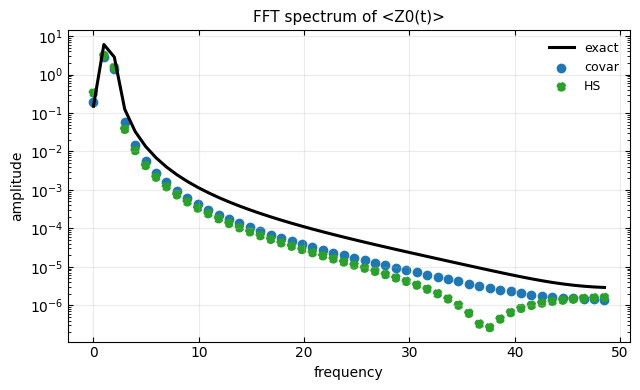

In [12]:
# ============================================================
# FFT analysis
# ============================================================
import numpy.fft as fft

def compute_fft(signal, dt, window=True):
    """
    Returns frequencies and amplitude spectrum
    """
    sig = np.asarray(signal, dtype=float)

    # remove DC component
    sig = sig - np.mean(sig)

    # optional window to reduce spectral leakage
    if window:
        w = np.hanning(len(sig))
        sig = sig * w

    # FFT
    spec = fft.rfft(sig)
    freqs = fft.rfftfreq(len(sig), d=dt)

    amp = np.abs(spec)

    return freqs, amp


freqs, amp_exact = compute_fft(exact, dt)
_, amp_covar = compute_fft(y_covar, dt)
_, amp_hs = compute_fft(y_hs, dt)

# ============================================================
# Plot FFT spectra
# ============================================================
plt.figure(figsize=(6.5, 4.0))

plt.plot(freqs[:50], amp_exact[:50], color="black", lw=2.2, label="exact")
plt.scatter(freqs[:50], amp_covar[:50], color="tab:blue", label="covar")
plt.scatter(freqs[:50], amp_hs[:50], color="tab:green", ls="--", label="HS")

plt.xlabel("frequency")
plt.ylabel("amplitude")
plt.title("FFT spectrum of <Z0(t)>")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()